
# Piecewise-constant optimization for single-qubit $\sigma_z$ NESS

This notebook replaces the Fourier ansatz for $J_x(t)$ by a **piecewise-constant** control over one period.

The physics is the same driven open single-qubit Lindblad model,
\[
\dot\rho = -i[H(t),\rho] + \gamma_\downarrow \,\mathcal D[\sigma_-]\rho + \gamma_\phi \,\mathcal D[\sigma_z]\rho,
\qquad
H(t)=\frac{1}{2}J_x(t)\sigma_x.
\]

Because the control is piecewise constant, each time slice is propagated with the **exact matrix exponential of the Liouvillian**. That is physically valid and, for this ansatz, exact slice-by-slice.

The default settings are tuned to target the same benchmark values as the Fourier notebook:
- target stroboscopic NESS $\langle \sigma_z \rangle \approx -0.791$
- target excited-state population $p_e \approx 0.896$

If your first run lands slightly above the target, raise `K_ctrl`, `n_random_starts`, or `maxiter_powell`.


In [1]:

import os
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, lu_factor, lu_solve
from scipy.optimize import minimize


In [2]:

# =========================
# Basic operators / helpers
# =========================

I2 = np.array([[1., 0.], [0., 1.]], dtype=complex)
sx = np.array([[0., 1.], [1., 0.]], dtype=complex)
sy = np.array([[0., -1j], [1j, 0.]], dtype=complex)
sz = np.array([[1., 0.], [0., -1.]], dtype=complex)
sigma_minus = np.array([[0., 1.], [0., 0.]], dtype=complex)  # |0><1|

def vec(A: np.ndarray) -> np.ndarray:
    return np.asarray(A, dtype=complex).reshape(-1, order="F")

def mat(v: np.ndarray) -> np.ndarray:
    return np.asarray(v, dtype=complex).reshape((2, 2), order="F")

def trace_vec() -> np.ndarray:
    return vec(I2)

def random_density(rng: np.random.Generator) -> np.ndarray:
    A = rng.standard_normal((2, 2)) + 1j * rng.standard_normal((2, 2))
    rho = A @ A.conj().T
    rho /= np.trace(rho)
    return rho

def sanitize_for_json(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()
    if isinstance(obj, (np.complexfloating, complex)):
        c = complex(obj)
        return [float(c.real), float(c.imag)]
    if isinstance(obj, dict):
        return {k: sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize_for_json(v) for v in obj]
    return obj

def ness_augmented_system(Phi: np.ndarray):
    n = Phi.shape[0]
    c = trace_vec().reshape(-1, 1)
    A = np.block([
        [np.eye(n, dtype=complex) - Phi, c],
        [c.T, np.zeros((1, 1), dtype=complex)]
    ])
    b = np.zeros((n + 1,), dtype=complex)
    b[-1] = 1.0
    return A, b

def lindblad_superoperator(H: np.ndarray, c_ops: list[np.ndarray]) -> np.ndarray:
    d = H.shape[0]
    Id = np.eye(d, dtype=complex)

    # vec convention: vec(A X B) = (B^T \otimes A) vec(X)
    L = -1j * (np.kron(Id, H) - np.kron(H.T, Id))
    for c in c_ops:
        cdgc = c.conj().T @ c
        L += np.kron(c.conj(), c)
        L -= 0.5 * np.kron(Id, cdgc)
        L -= 0.5 * np.kron(cdgc.T, Id)
    return L


In [10]:

# =========================
# Parameters
# =========================

gamma_down = 4.7
gamma_phi  = 0.3

# Number of constant-control bins in one period.
# 16 is a good quick run; 24 or 32 gives the optimizer more freedom to emulate pulse-like controls.
K_ctrl = 24

# Number of substeps per control bin only for plotting the micromotion (not for optimization).
plot_substeps_per_bin = 12

J_bounds = 70
T_bounds = (0.02, 2.0)

seed = 1
n_random_starts = 2
maxiter_powell = 80
maxiter_lbfgsb = 80

# Targets from the Fourier notebook (for comparison)
sigma_z_target = -0.791211
p_exc_target = 0.895606

rng = np.random.default_rng(seed)
bounds = [(-J_bounds, J_bounds)] * K_ctrl + [T_bounds]

# Collapse operators
c_ops = []
if gamma_down != 0.0:
    c_ops.append(np.sqrt(gamma_down) * sigma_minus)
if gamma_phi != 0.0:
    c_ops.append(np.sqrt(gamma_phi) * sz)

# Superoperator decomposition: L(J) = L0 + J * Lx
Id = np.eye(2, dtype=complex)
Lx = -1j * 0.5 * (np.kron(Id, sx) - np.kron(sx.T, Id))
L0 = np.zeros((4, 4), dtype=complex)
for c in c_ops:
    cdgc = c.conj().T @ c
    L0 += np.kron(c.conj(), c)
    L0 -= 0.5 * np.kron(Id, cdgc)
    L0 -= 0.5 * np.kron(cdgc.T, Id)


In [15]:

# =========================
# Piecewise-constant control model
# =========================

def period_map_piecewise(J_bins: np.ndarray, T: float) -> np.ndarray:
    """One-period 4x4 Floquet map for stroboscopic sampling at t = nT."""
    J_bins = np.asarray(J_bins, dtype=float)
    dt = float(T) / len(J_bins)

    Phi = np.eye(4, dtype=complex)
    for J in J_bins:
        G = expm((L0 + float(J) * Lx) * dt)
        Phi = G @ Phi
    return Phi

def stroboscopic_ness_piecewise(J_bins: np.ndarray, T: float):
    Phi = period_map_piecewise(J_bins, T)
    A, b = ness_augmented_system(Phi)
    LU = lu_factor(A)
    x = lu_solve(LU, b)
    r_star = x[:4]

    sx_star = float(np.real((vec(sx).conj().T @ r_star).item()))
    sy_star = float(np.real((vec(sy).conj().T @ r_star).item()))
    sz_star = float(np.real((vec(sz).conj().T @ r_star).item()))
    p_exc_star = 0.5 * (1.0 - sz_star)

    return {
        "Phi": Phi,
        "r_star": r_star,
        "sx_star": sx_star,
        "sy_star": sy_star,
        "sz_star": sz_star,
        "p_exc_star": p_exc_star,
    }

def objective(x: np.ndarray) -> float:
    J_bins = x[:K_ctrl]
    T = float(x[K_ctrl])
    diag = stroboscopic_ness_piecewise(J_bins, T)
    return float(diag["sz_star"])  # minimize <sigma_z> to maximize excited-state population

def seed_bank() -> list[np.ndarray]:
    """Warm starts that encourage pulse-like solutions plus a few random starts."""
    seeds = []

    # 1) single strong pulse near the end of the period (sampled just after the pulse)
    for width in [1, 2, 3, 4]:
        J = np.zeros(K_ctrl, dtype=float)
        J[-width:] = J_bounds
        T = np.clip(np.pi * K_ctrl / (J_bounds * width), *T_bounds)
        seeds.append(np.concatenate([J, [T]]))

    # 2) split pulse across the periodic boundary
    for width in [2, 3, 4]:
        J = np.zeros(K_ctrl, dtype=float)
        left = width // 2
        right = width - left
        J[:left] = J_bounds
        J[-right:] = J_bounds
        T = np.clip(np.pi * K_ctrl / (J_bounds * width), *T_bounds)
        seeds.append(np.concatenate([J, [T]]))

    # 3) alternating-sign pulse-like starts
    for width in [2, 3]:
        J = np.zeros(K_ctrl, dtype=float)
        J[-width:] = J_bounds
        J[:width] = -0.35 * J_bounds
        T = np.clip(1.15 * np.pi * K_ctrl / (J_bounds * width), *T_bounds)
        seeds.append(np.concatenate([J, [T]]))

    # 4) a few random starts
    for _ in range(n_random_starts):
        J = rng.uniform(-0.25 * J_bounds, 0.25 * J_bounds, size=K_ctrl)
        T = rng.uniform(*T_bounds)
        seeds.append(np.concatenate([J, [T]]))

    return seeds

def run_local_optimization(x0: np.ndarray):
    hist = {"J": [], "T": []}

    def cb_powell(xk):
        diag = stroboscopic_ness_piecewise(xk[:K_ctrl], float(xk[K_ctrl]))
        hist["J"].append(diag["sz_star"])
        hist["T"].append(float(xk[K_ctrl]))

    res1 = minimize(
        objective, x0, method="Powell", bounds=bounds,
        callback=cb_powell,
        options={"maxiter": maxiter_powell, "xtol": 1e-3, "ftol": 1e-4, "disp": False}
    )

    x1 = np.array(res1.x, dtype=float)

    def cb_lbfgsb(xk):
        diag = stroboscopic_ness_piecewise(xk[:K_ctrl], float(xk[K_ctrl]))
        hist["J"].append(diag["sz_star"])
        hist["T"].append(float(xk[K_ctrl]))

    res2 = minimize(
        objective, x1, method="L-BFGS-B", bounds=bounds,
        callback=cb_lbfgsb,
        options={"maxiter": maxiter_lbfgsb, "ftol": 1e-12, "gtol": 1e-6}
    )

    x_best = np.array(res2.x if np.isfinite(res2.fun) else res1.x, dtype=float)
    fun_best = float(res2.fun if np.isfinite(res2.fun) else res1.fun)

    return {
        "res_powell": res1,
        "res_refine": res2,
        "x_best": x_best,
        "fun_best": fun_best,
        "history": hist,
    }


In [16]:

# =========================
# Run optimization + save
# =========================

run_dir = Path("results") / "runs"
run_dir.mkdir(parents=True, exist_ok=True)

best = None
t_all = time.time()
starts = seed_bank()

for i, x0 in enumerate(starts):
    print(f"--- start {i+1}/{len(starts)} ---")
    out = run_local_optimization(x0)

    x_best = out["x_best"]
    diag = stroboscopic_ness_piecewise(x_best[:K_ctrl], float(x_best[K_ctrl]))

    print(f"    T = {x_best[K_ctrl]:.6f}")
    print(f"    <sigma_z>_NESS = {diag['sz_star']:.6f}")
    print(f"    p_exc_NESS     = {diag['p_exc_star']:.6f}")

    if (best is None) or (diag["sz_star"] < best["diag"]["sz_star"]):
        best = {
            "x": x_best,
            "diag": diag,
            "history": out["history"],
        }

print("\nOptimization finished in %.2f s" % (time.time() - t_all))

J_best = np.asarray(best["x"][:K_ctrl], dtype=float)
T_best = float(best["x"][K_ctrl])
diag_best = best["diag"]
Phi_best = diag_best["Phi"]
r_star_best = diag_best["r_star"]

# --- Construct one-period control array on a dense plotting grid ---
plot_substeps = plot_substeps_per_bin
dt = T_best / K_ctrl
n_dense = K_ctrl * plot_substeps
t_one = np.linspace(0.0, T_best, n_dense + 1)
Jx_t = np.repeat(J_best, plot_substeps)
Jx_t = np.concatenate([Jx_t, [Jx_t[-1]]])

# --- Micromotion over 3 periods starting from the stroboscopic NESS ---
n_periods = 3
times = [0.0]
states = [r_star_best.copy()]
r_curr = r_star_best.copy()

for period in range(n_periods):
    for j in range(K_ctrl):
        Jj = float(J_best[j])
        Lj = L0 + Jj * Lx

        # start state of this slice
        r_slice0 = r_curr.copy()

        # substep points for plotting inside the slice
        for m in range(1, plot_substeps + 1):
            tau = m * (dt / plot_substeps)
            r_tau = expm(Lj * tau) @ r_slice0
            times.append(period * T_best + j * dt + tau)
            states.append(r_tau)

        # exact update to the next slice boundary
        r_curr = expm(Lj * dt) @ r_slice0

states = np.array(states, dtype=complex)
times = np.array(times, dtype=float)

bx = np.real(states @ vec(sx))
by = np.real(states @ vec(sy))
bz = np.real(states @ vec(sz))
p_exc = 0.5 * (1.0 - bz)

# stroboscopic points at t = nT
strobe_times = np.arange(0, n_periods + 1, dtype=float) * T_best
strobe_idx = [int(np.argmin(np.abs(times - ts))) for ts in strobe_times]
strobe_idx = np.array(strobe_idx, dtype=int)

# convergence under the one-period map
K_conv = 20
r = vec(random_density(np.random.default_rng(0)))
conv_dist = np.zeros(K_conv + 1, dtype=float)
conv_dist[0] = float(np.linalg.norm(r - r_star_best))
for k in range(K_conv):
    r = Phi_best @ r
    conv_dist[k + 1] = float(np.linalg.norm(r - r_star_best))

stamp = time.strftime("%Y-%m-%d_%H%M%S")
tag = f"{stamp}_sigmaZ_Jx_piecewise_optT_K{K_ctrl}"

meta = {
    "gamma_down": gamma_down,
    "gamma_phi": gamma_phi,
    "K_ctrl": K_ctrl,
    "plot_substeps_per_bin": plot_substeps_per_bin,
    "J_bounds": J_bounds,
    "T_bounds": T_bounds,
    "seed": seed,
    "sigma_z_target": sigma_z_target,
    "p_exc_target": p_exc_target,
}

summary = {
    "T_best": T_best,
    "sz_star": diag_best["sz_star"],
    "p_exc_star": diag_best["p_exc_star"],
    "target_hit_sigma_z": bool(diag_best["sz_star"] <= sigma_z_target),
    "target_hit_p_exc": bool(diag_best["p_exc_star"] >= p_exc_target),
    "elapsed_s": time.time() - t_all,
}

json_path = run_dir / f"{tag}.json"
npz_path = run_dir / f"{tag}.npz"

json_path.write_text(json.dumps(sanitize_for_json({
    "meta": meta,
    "summary": summary,
    "J_best": J_best,
    "history": best["history"],
}), indent=2))

np.savez(
    npz_path,
    J_best=J_best,
    T=T_best,
    t1=t_one,
    Jx_t=Jx_t,
    t_steps=times,
    bx=bx, by=by, bz=bz, p_exc=p_exc,
    strobe_idx=strobe_idx,
    conv_dist=conv_dist,
    sx_star=diag_best["sx_star"],
    sy_star=diag_best["sy_star"],
    sz_star=diag_best["sz_star"],
    p_exc_star=diag_best["p_exc_star"],
    hist_J=np.array(best["history"]["J"], dtype=float),
    hist_T=np.array(best["history"]["T"], dtype=float),
    **meta,
)

print("\n================ BEST PIECEWISE RESULT ================")
print(f"T_best              = {T_best:.6f}")
print(f"<sigma_z>_NESS      = {diag_best['sz_star']:.6f}")
print(f"excited population  = {diag_best['p_exc_star']:.6f}")
print(f"target sigma_z      = {sigma_z_target:.6f}")
print(f"target p_exc        = {p_exc_target:.6f}")
print("hit sigma_z target? ", diag_best["sz_star"] <= sigma_z_target)
print("hit p_exc target?   ", diag_best["p_exc_star"] >= p_exc_target)
print("\nSaved:")
print(" ", json_path)
print(" ", npz_path)


--- start 1/11 ---
    T = 2.262661
    <sigma_z>_NESS = -0.694946
    p_exc_NESS     = 0.847473
--- start 2/11 ---
    T = 2.944373
    <sigma_z>_NESS = -0.447557
    p_exc_NESS     = 0.723778
--- start 3/11 ---
    T = 4.272656
    <sigma_z>_NESS = -0.128088
    p_exc_NESS     = 0.564044
--- start 4/11 ---
    T = 3.204625
    <sigma_z>_NESS = -0.128082
    p_exc_NESS     = 0.564041
--- start 5/11 ---
    T = 1.342628
    <sigma_z>_NESS = -0.710654
    p_exc_NESS     = 0.855327
--- start 6/11 ---
    T = 0.864013
    <sigma_z>_NESS = -0.870860
    p_exc_NESS     = 0.935430
--- start 7/11 ---
    T = 1.138446
    <sigma_z>_NESS = -0.690377
    p_exc_NESS     = 0.845189
--- start 8/11 ---
    T = 0.789570
    <sigma_z>_NESS = -0.876779
    p_exc_NESS     = 0.938389
--- start 9/11 ---
    T = 3.769981
    <sigma_z>_NESS = -0.163263
    p_exc_NESS     = 0.581631
--- start 10/11 ---
    T = 2.369970
    <sigma_z>_NESS = -0.556902
    p_exc_NESS     = 0.778451
--- start 11/11 ---
    T = 0

In [19]:

# =========================
# Plot style helpers
# =========================

from matplotlib.ticker import AutoMinorLocator, MaxNLocator

EPS = 1.0
JX_LABEL = r"$J_x/\epsilon$"

FIGSIZE_MAIN = (7.2, 4.8)
DPI = 300

LW_MAIN = 2.4
SPINE_LW = 1.8
TICK_LW = 1.4
TICK_LEN = 6
TITLE_FS = 16
LABEL_FS = 15
TICK_FS = 12
LEGEND_FS = 12

def set_plot_style():
    plt.rcParams.update({
        "figure.dpi": DPI,
        "savefig.dpi": DPI,
        "figure.figsize": FIGSIZE_MAIN,
        "font.size": 13,
        "axes.labelsize": LABEL_FS,
        "axes.titlesize": TITLE_FS,
        "xtick.labelsize": TICK_FS,
        "ytick.labelsize": TICK_FS,
        "legend.fontsize": LEGEND_FS,
        "axes.linewidth": SPINE_LW,
        "lines.linewidth": LW_MAIN,
        "lines.markersize": 5.5,
        "legend.frameon": True,
        "mathtext.fontset": "dejavusans",
        "figure.constrained_layout.use": False,
    })

def beautify_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(SPINE_LW)
        spine.set_color("black")

    ax.tick_params(
        axis="both", which="major",
        direction="in", top=True, right=True,
        length=TICK_LEN, width=TICK_LW, colors="black"
    )
    ax.tick_params(
        axis="both", which="minor",
        direction="in", top=True, right=True,
        length=3.5, width=1.0, colors="black"
    )

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(False)
    ax.margins(x=0.02, y=0.05)

def add_legend(ax, **kwargs):
    leg = ax.legend(facecolor="white", edgecolor="black", frameon=True, **kwargs)
    leg.get_frame().set_linewidth(1.2)
    return leg


C:\Users\py.wchen43lab.user\AppData\Local\Temp\ipykernel_19588\4109861613.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


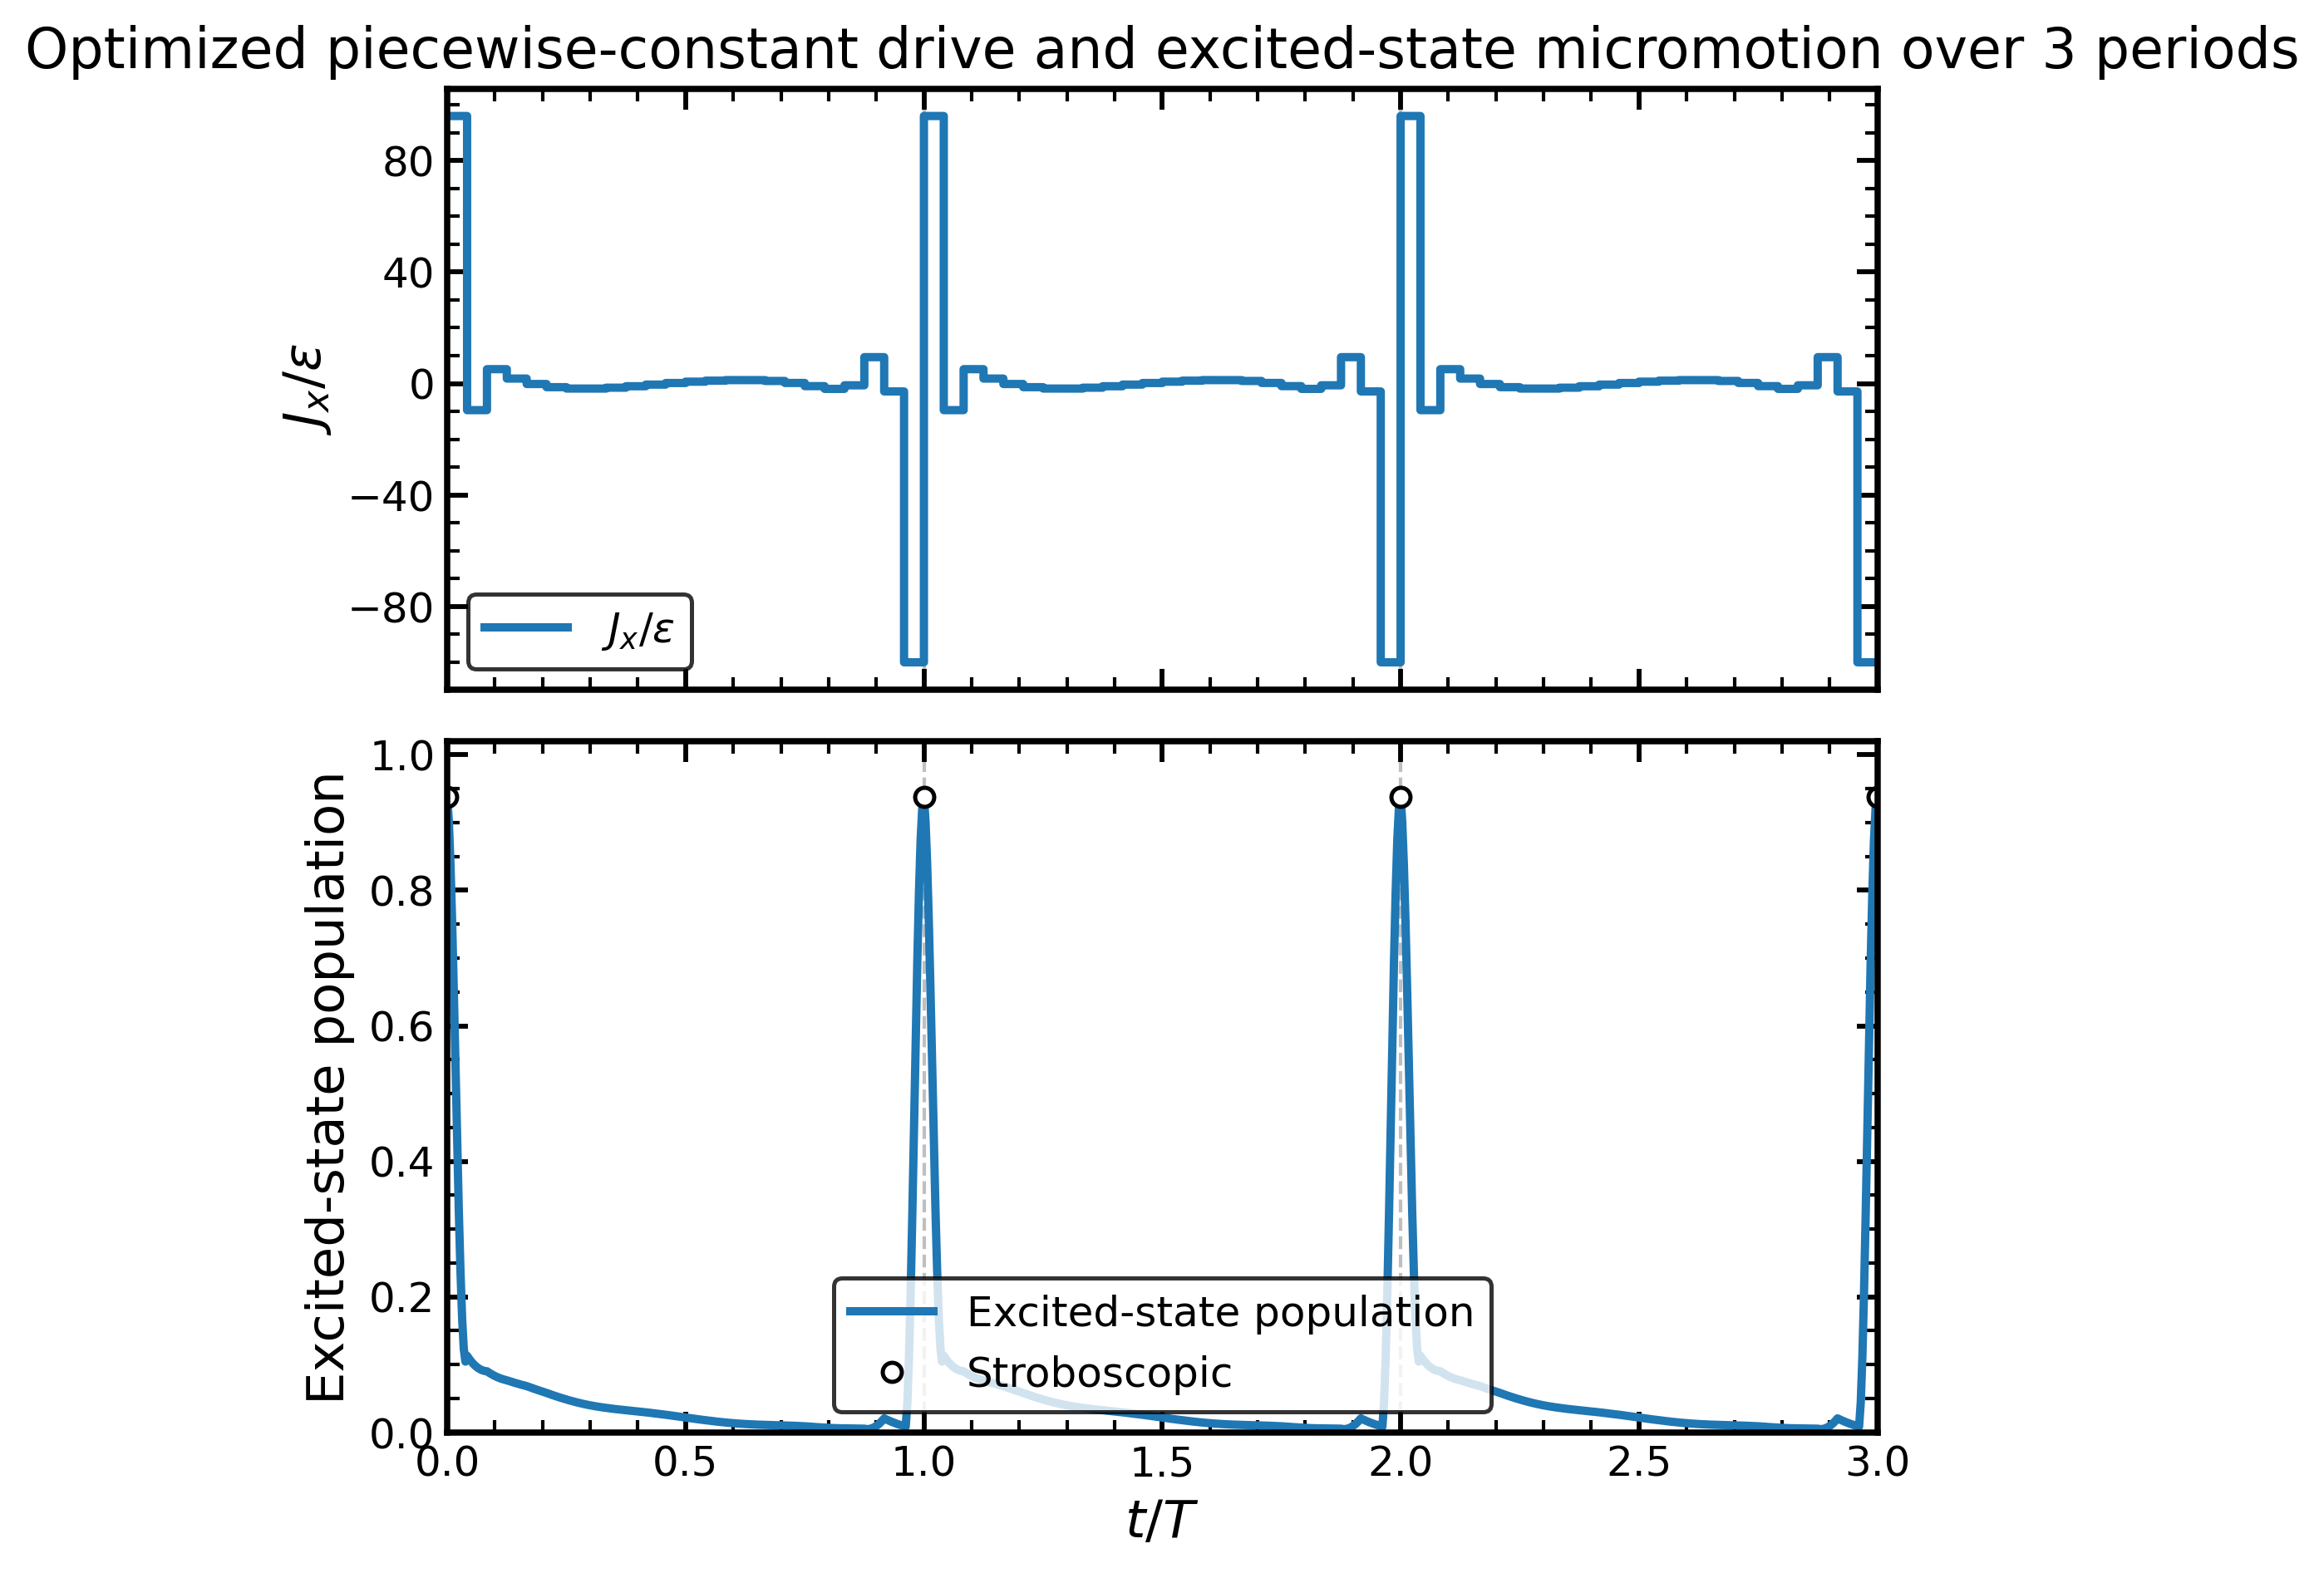

Saved figure: results\figures\2026-03-17_023929_sigmaZ_Jx_piecewise_optT_K24_control_and_excited_population_3periods.png/.pdf
Best stroboscopic NESS <sigma_z> = -0.876779
Best stroboscopic NESS p_exc     = 0.938389


In [20]:

# =========================
# Combined figure:
# control + excited-state micromotion over 3 periods
# =========================

set_plot_style()

fig_dir = Path("results") / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# use the result generated above
tau_ctrl = t_one / T_best
tau_mic = times / T_best
tau_strobe = times[strobe_idx] / T_best

# repeat one-period control over 3 periods
tau_ctrl_3 = np.concatenate([tau_ctrl[:-1] + m for m in range(n_periods)] + [tau_ctrl[-1:] + (n_periods - 1)])
Jx_3 = np.tile(Jx_t[:-1], n_periods)
Jx_3 = np.concatenate([Jx_3, [Jx_3[-1]]])

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7.4, 7.0),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.15], "hspace": 0.08}
)

# top: control
ax1.step(tau_ctrl_3, Jx_3, where="post", color="tab:blue", label=JX_LABEL)
ax1.set_ylabel(JX_LABEL)
ax1.set_title(r"Optimized piecewise-constant drive and excited-state micromotion over 3 periods")
beautify_axes(ax1)
ax1.set_xlim(0.0, float(n_periods))
for m in range(1, n_periods):
    ax1.axvline(m, color="0.75", linestyle="--", linewidth=1.0, zorder=0)
add_legend(ax1, loc="lower left")

# bottom: excited-state population
ax2.plot(tau_mic, p_exc, color="tab:blue", label="Excited-state population")
ax2.plot(
    tau_strobe,
    p_exc[strobe_idx],
    linestyle="None",
    marker="o",
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.2,
    label="Stroboscopic"
)
ax2.set_xlabel(r"$t/T$")
ax2.set_ylabel("Excited-state population")
beautify_axes(ax2)
ax2.set_xlim(0.0, float(n_periods))
ax2.set_ylim(0.0, 1.02)
ax2.set_xticks(np.arange(0, n_periods + 0.001, 0.5))
for m in range(1, n_periods):
    ax2.axvline(m, color="0.75", linestyle="--", linewidth=1.0, zorder=0)
add_legend(ax2, loc="lower center")

base = fig_dir / f"{tag}_control_and_excited_population_3periods"
fig.tight_layout()
fig.savefig(str(base) + ".png", bbox_inches="tight")
fig.savefig(str(base) + ".pdf", bbox_inches="tight")
plt.show()

print(f"Saved figure: {base}.png/.pdf")
print(f"Best stroboscopic NESS <sigma_z> = {diag_best['sz_star']:.6f}")
print(f"Best stroboscopic NESS p_exc     = {diag_best['p_exc_star']:.6f}")



### Notes

- If you want a **quicker test**, set `K_ctrl = 16`.
- If you want to push harder toward a pulse-train solution, try:
  - `K_ctrl = 32`
  - `n_random_starts = 4`
  - `maxiter_powell = 120`
- The benchmark comparison is only fair if the **same amplitude bound** and **same period window** are used for both Fourier and piecewise controls.
